In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
0
1
Tesla T4


In [2]:
!pip install kagglehub

In [4]:
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import kagglehub
kagglehub.login()

# Get data from Kaggle
data_path = kagglehub.competition_download("demand-forecasting-kernels-only")
print(f"Data successfully downloaded to: {data_path}")

train_df = pd.read_csv(f"{data_path}/train.csv")

print(train_df.head())

100%|██████████| 3.29M/3.29M [00:01<00:00, 2.16MB/s]

Extracting files...


Data successfully downloaded to: /root/.cache/kagglehub/competitions/demand-forecasting-kernels-only
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10


In [5]:
# Date to split data
split_date = '2017-10-01'

# Feature Engineering
# Break date into year, month, and day of week
train_df['date'] = pd.to_datetime(train_df['date'])
train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day_of_week'] = train_df['date'].dt.dayofweek

# Create cyclic features for day and month
train_df['day_sin'] = np.sin(2 * np.pi * train_df['day_of_week'] / 7)
train_df['day_cos'] = np.cos(2 * np.pi * train_df['day_of_week'] / 7)
train_df['month_sin'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['month'] / 12)

# Downcast to float32 to save RAM
train_df['sales'] = train_df['sales'].astype('float32')

# Limit data to just one store and item
local_df = train_df[(train_df['store'] == 1) & (train_df['item'] == 1)].copy()

# Train/Val Split
train_split = local_df[local_df['date'] < split_date].copy()
val_split = local_df[local_df['date'] >= split_date].copy()


# Select features for the model
features = ['sales', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'year']

# Scale all features for the network input
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_split[features])

# Use .transform() on validation so it uses the Min/Max rules learned from Train
val_scaled = scaler.transform(val_split[features])

target_scaler = MinMaxScaler()
target_scaler.fit(train_split[['sales']])

class DemandDataset(Dataset):
    def __init__(self, data_array, window_size):
        # Store the flat 2D array, not the massive 3D windowed array
        self.data = torch.tensor(data_array, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        # Total available windows
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # Create the specific window ONLY when requested by the DataLoader
        X = self.data[idx : idx + self.window_size, :]
        
        # Target (y) is the 'sales' feature (index 0) on the day AFTER the window
        y = self.data[idx + self.window_size, 0] 
        
        return X, y

# Initialize Dataset and DataLoader
window_size = 30

train_dataset = DemandDataset(train_scaled, window_size)
val_dataset = DemandDataset(val_scaled, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
# LSTM model for single store-item
class LocalDemandForecaster(nn.Module):
    # input_size is 6: sales, day_sin, day_cos, month_sin, month_cos, year
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, output_size=1):
        super(LocalDemandForecaster, self).__init__()
        
        # LSTM layer(s)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # The fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # LSTM returns the output sequence AND a tuple of (hidden_state, cell_state)
        out, _ = self.lstm(x)
        
        # Grab the output from the final time-step of the 30-day window
        final_timestep_out = out[:, -1, :]
        
        prediction = self.fc(final_timestep_out)
        return prediction.squeeze()

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LocalDemandForecaster(input_size=6, hidden_size=64, num_layers=2).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss (MSE): {avg_loss:.6f}')

Epoch [10/50], Average Loss (MSE): 0.011569
Epoch [20/50], Average Loss (MSE): 0.010215
Epoch [30/50], Average Loss (MSE): 0.009953
Epoch [40/50], Average Loss (MSE): 0.009657
Epoch [50/50], Average Loss (MSE): 0.009563


In [11]:
print(f"Total batches per epoch: {len(train_loader)}")

Total batches per epoch: 54


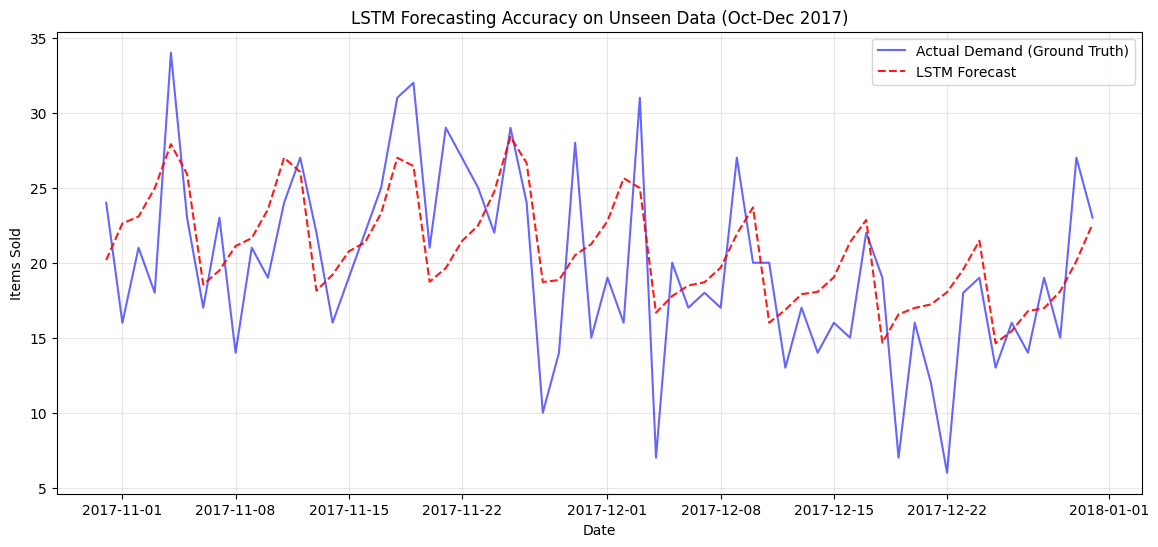

In [ ]:
# --- 5. Evaluate on Unseen Validation Data ---
model.eval()
val_predictions = []
val_actuals = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        
        preds = model(batch_X)
        val_predictions.extend(preds.cpu().numpy())
        val_actuals.extend(batch_y.numpy())

# Un-scale the numbers back to real inventory item counts
real_preds = target_scaler.inverse_transform(np.array(val_predictions).reshape(-1, 1))
real_actuals = target_scaler.inverse_transform(np.array(val_actuals).reshape(-1, 1))

# Extract the corresponding dates for the plot
# (We skip the first 'window_size' dates because they were used to predict the first point)
plot_dates = val_split['date'].iloc[window_size:]

# --- 6. Plot the Final Accuracy ---
plt.figure(figsize=(14, 6))
plt.plot(plot_dates, real_actuals, label='Actual Demand (Ground Truth)', color='blue', alpha=0.6)
plt.plot(plot_dates, real_preds, label='LSTM Forecast', color='red', linestyle='--', alpha=0.9)
plt.title('LSTM Forecasting Accuracy on Unseen Data (Oct-Dec 2017)')
plt.xlabel('Date')
plt.ylabel('Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Flatten the arrays so they are simple 1D lists for easier math
actuals = real_actuals.flatten()
preds = real_preds.flatten()

# 1. Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(preds - actuals))

# 2. Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean((preds - actuals) ** 2))

# 3. Calculate SMAPE (The Kaggle Competition Metric)
def calculate_smape(actual, predicted):
    # Avoid division by zero by adding a tiny number (epsilon)
    epsilon = 0.1
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0 + epsilon
    diff = np.abs(actual - predicted) / denominator
    # Multiply by 100 to get a percentage
    return 100 * np.mean(diff)

smape = calculate_smape(actuals, preds)

# --- Print the Results ---
print("--- Model Accuracy ---")
print(f"MAE:   {mae:.2f} items off per day (on average)")
print(f"RMSE:  {rmse:.2f} items (punishes larger errors)")
print(f"SMAPE: {smape:.2f}% (Kaggle Official Score)")

--- Model Accuracy ---
MAE:   3.95 items off per day (on average)
RMSE:  4.79 items (punishes larger errors)
SMAPE: 21.25% (Kaggle Official Score)


In [14]:
store1_df = train_df[train_df['store'] == 1].copy()

train_split = store1_df[store1_df['date'] < split_date].copy()
val_split = store1_df[store1_df['date'] >= split_date].copy()

features = ['sales', 'item', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'year']

# Scale all features for the network input
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_split[features])
# Use .transform() on validation so it uses the Min/Max rules learned from Train
val_scaled = scaler.transform(val_split[features])

target_scaler = MinMaxScaler()
target_scaler.fit(train_split[['sales']])

class GroupedDemandDataset(Dataset):
    def __init__(self, data_array, df_split, window_size):
        self.data = torch.tensor(data_array, dtype=torch.float32)
        self.window_size = window_size
        self.valid_indices = []
        
        # Get the item ID for every single row in the dataframe
        items = df_split['item'].values
        
        # Slide through the data and only save "safe" windows
        for i in range(len(items) - window_size):
            # If the item ID at Day 1 matches the item ID at Day 30...
            # It means this window perfectly encapsulates a single product!
            if items[i] == items[i + window_size]:
                self.valid_indices.append(i)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_row = self.valid_indices[idx]
        X = self.data[start_row : start_row + self.window_size, :]
        y = self.data[start_row + self.window_size, 0] # Sales is index 0
        return X, y

# --- 5. Build DataLoaders ---
window_size = 30
train_dataset = GroupedDemandDataset(train_scaled, train_split, window_size)
val_dataset = GroupedDemandDataset(val_scaled, val_split, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [15]:
class UnifiedStoreForecaster(nn.Module):
    # input_size is now 7! (Sales, Item, Day Sin/Cos, Month Sin/Cos, Year)
    def __init__(self, input_size=7, hidden_size=128, num_layers=2, output_size=1):
        super(UnifiedStoreForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        final_timestep_out = out[:, -1, :]
        prediction = self.fc(final_timestep_out)
        return prediction.squeeze()

In [16]:
model = UnifiedStoreForecaster().to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 # Dropped to 10 epochs since the model sees 50x more data per epoch!

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss (MSE): {total_loss / len(train_loader):.6f}')

Epoch [1/10], Train Loss (MSE): 0.003466
Epoch [2/10], Train Loss (MSE): 0.002586
Epoch [3/10], Train Loss (MSE): 0.002520
Epoch [4/10], Train Loss (MSE): 0.002473
Epoch [5/10], Train Loss (MSE): 0.002436
Epoch [6/10], Train Loss (MSE): 0.002423
Epoch [7/10], Train Loss (MSE): 0.002410
Epoch [8/10], Train Loss (MSE): 0.002372
Epoch [9/10], Train Loss (MSE): 0.002345
Epoch [10/10], Train Loss (MSE): 0.002334


In [17]:
print(f"Total batches per epoch: {len(train_loader)}")

Total batches per epoch: 2663


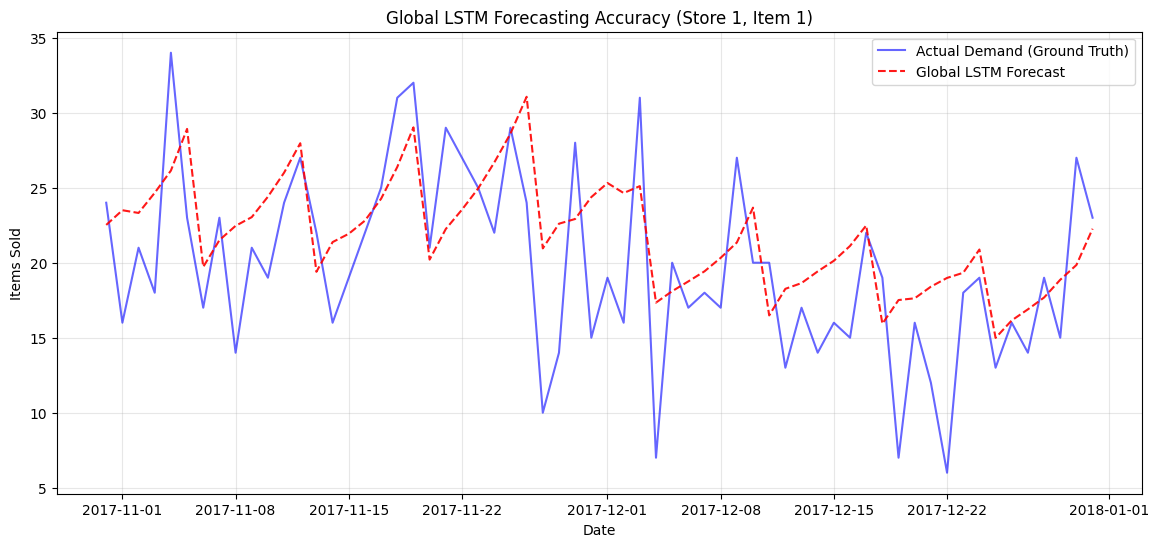

In [18]:
# --- 1. Evaluate on Unseen Validation Data ---
model.eval()
val_predictions = []
val_actuals = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        
        preds = model(batch_X)
        val_predictions.extend(preds.cpu().numpy())
        val_actuals.extend(batch_y.numpy())

# Un-scale the numbers back to real inventory item counts
real_preds = target_scaler.inverse_transform(np.array(val_predictions).reshape(-1, 1)).flatten()
real_actuals = target_scaler.inverse_transform(np.array(val_actuals).reshape(-1, 1)).flatten()

# --- 2. Align Predictions with Dates, Items, AND Stores ---
target_indices = [idx + window_size for idx in val_dataset.valid_indices]

results_df = pd.DataFrame({
    'date': val_split.iloc[target_indices]['date'].values,
    'item': val_split.iloc[target_indices]['item'].values,
    'actual_sales': real_actuals,
    'predicted_sales': real_preds
})

# --- 3. Filter for ONE Specific Store & Item ---
item_to_plot = 1   # Pick an item (1-50)

# Filter by BOTH store and item to avoid overlapping data
plot_df = results_df[(results_df['item'] == item_to_plot)].copy()

# Force chronological order to prevent "spaghetti" lines
plot_df = plot_df.sort_values('date')

# --- 4. Plot the Clean Data ---
plt.figure(figsize=(14, 6))
plt.plot(plot_df['date'], plot_df['actual_sales'], label='Actual Demand (Ground Truth)', color='blue', alpha=0.6)
plt.plot(plot_df['date'], plot_df['predicted_sales'], label='Global LSTM Forecast', color='red', linestyle='--', alpha=0.9)
plt.title(f'Global LSTM Forecasting Accuracy (Store 1, Item {item_to_plot})')
plt.xlabel('Date')
plt.ylabel('Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
def calculate_smape(actual, predicted):
    # Avoid division by zero by adding a tiny number (epsilon)
    epsilon = 0.1
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0 + epsilon
    diff = np.abs(actual - predicted) / denominator
    return 100 * np.mean(diff)

# --- 1. Evaluate the Specific Item (from your graph) ---
# We use plot_df which is already filtered for your specific item
actuals_item = plot_df['actual_sales'].values
preds_item = plot_df['predicted_sales'].values

mae_item = np.mean(np.abs(preds_item - actuals_item))
rmse_item = np.sqrt(np.mean((preds_item - actuals_item) ** 2))
smape_item = calculate_smape(actuals_item, preds_item)

# --- 2. Evaluate the Entire Store (All 50 Items) ---
# We use results_df which contains every product
actuals_all = results_df['actual_sales'].values
preds_all = results_df['predicted_sales'].values

mae_all = np.mean(np.abs(preds_all - actuals_all))
rmse_all = np.sqrt(np.mean((preds_all - actuals_all) ** 2))
smape_all = calculate_smape(actuals_all, preds_all)

# --- Print the Results ---
print(f"--- Accuracy for Item {item_to_plot} ---")
print(f"MAE:   {mae_item:.2f} items off per day (on average)")
print(f"RMSE:  {rmse_item:.2f} items")
print(f"SMAPE: {smape_item:.2f}%\n")

print(f"--- OVERALL Accuracy (Store 1, All 50 Items) ---")
print(f"MAE:   {mae_all:.2f} items off per day (on average)")
print(f"RMSE:  {rmse_all:.2f} items")
print(f"SMAPE: {smape_all:.2f}% (Estimated Kaggle Score)")

--- Accuracy for Item 1 ---
MAE:   4.25 items off per day (on average)
RMSE:  5.24 items
SMAPE: 22.48%

--- OVERALL Accuracy (Store 1, All 50 Items) ---
MAE:   6.28 items off per day (on average)
RMSE:  8.19 items
SMAPE: 14.60% (Estimated Kaggle Score)


In [6]:
global_df = train_df.copy()

global_df = global_df.sort_values(['store', 'item', 'date']) 

train_split = global_df[global_df['date'] < split_date].copy()
val_split = global_df[global_df['date'] >= split_date].copy()

features = ['sales', 'store', 'item', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'year']

# Scale all features for the network input
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_split[features])
# Use .transform() on validation so it uses the Min/Max rules learned from Train
val_scaled = scaler.transform(val_split[features])

target_scaler = MinMaxScaler()
target_scaler.fit(train_split[['sales']])

class GroupedDemandDataset(Dataset):
    def __init__(self, data_array, df_split, window_size):
        self.data = torch.tensor(data_array, dtype=torch.float32)
        self.window_size = window_size
        self.valid_indices = []
        
        # Get the item ID for every single row in the dataframe
        items = df_split['item'].values
        stores = df_split['store'].values
        
        # Slide through the data and only save "safe" windows
        for i in range(len(items) - window_size):
            # If the item ID at Day 1 matches the item ID at Day 30...
            # It means this window perfectly encapsulates a single product!
            if items[i] == items[i + window_size]:
                self.valid_indices.append(i)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_row = self.valid_indices[idx]
        X = self.data[start_row : start_row + self.window_size, :]
        y = self.data[start_row + self.window_size, 0] # Sales is index 0
        return X, y

# --- 5. Build DataLoaders ---
window_size = 30
train_dataset = GroupedDemandDataset(train_scaled, train_split, window_size)
val_dataset = GroupedDemandDataset(val_scaled, val_split, window_size)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [7]:
# --- 6. The Global Model ---
class GlobalStoreForecaster(nn.Module):
    # input_size is now 8!
    def __init__(self, input_size=8, hidden_size=128, num_layers=2, output_size=1):
        super(GlobalStoreForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        final_timestep_out = out[:, -1, :]
        prediction = self.fc(final_timestep_out)
        return prediction.squeeze()

# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GlobalStoreForecaster().to(device)

In [9]:
model = GlobalStoreForecaster().to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss (MSE): {total_loss / len(train_loader):.6f}')

Epoch [1/10], Train Loss (MSE): 0.001448
Epoch [2/10], Train Loss (MSE): 0.001173
Epoch [3/10], Train Loss (MSE): 0.001131
Epoch [4/10], Train Loss (MSE): 0.001107
Epoch [5/10], Train Loss (MSE): 0.001096
Epoch [6/10], Train Loss (MSE): 0.001085
Epoch [7/10], Train Loss (MSE): 0.001082
Epoch [8/10], Train Loss (MSE): 0.001083
Epoch [9/10], Train Loss (MSE): 0.001072
Epoch [10/10], Train Loss (MSE): 0.001072


In [10]:
print(f"Total batches per epoch: {len(train_loader)}")

Total batches per epoch: 3329


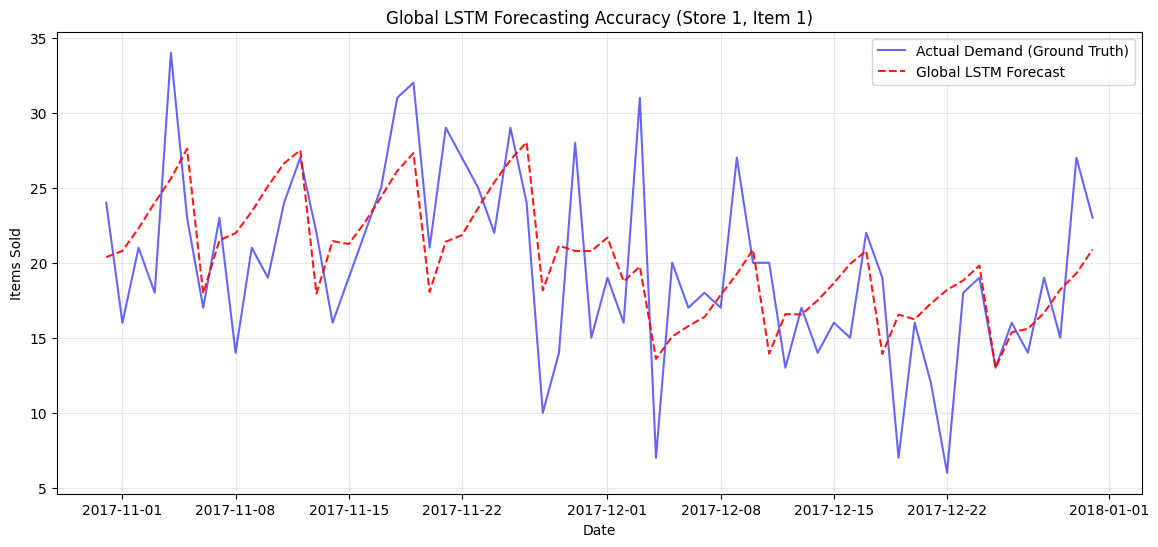

In [11]:
# --- 1. Evaluate on Unseen Validation Data ---
model.eval()
val_predictions = []
val_actuals = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        
        preds = model(batch_X)
        val_predictions.extend(preds.cpu().numpy())
        val_actuals.extend(batch_y.numpy())

# Un-scale the numbers back to real inventory item counts
real_preds = target_scaler.inverse_transform(np.array(val_predictions).reshape(-1, 1)).flatten()
real_actuals = target_scaler.inverse_transform(np.array(val_actuals).reshape(-1, 1)).flatten()

# --- 2. Align Predictions with Dates, Items, AND Stores ---
target_indices = [idx + window_size for idx in val_dataset.valid_indices]

results_df = pd.DataFrame({
    'date': val_split.iloc[target_indices]['date'].values,
    'store': val_split.iloc[target_indices]['store'].values, # Added this for Global!
    'item': val_split.iloc[target_indices]['item'].values,
    'actual_sales': real_actuals,
    'predicted_sales': real_preds
})

# --- 3. Filter for ONE Specific Store & Item ---
store_to_plot = 1  # Pick a store (1-10)
item_to_plot = 1   # Pick an item (1-50)

# Filter by BOTH store and item to avoid overlapping data
plot_df = results_df[(results_df['store'] == store_to_plot) & 
                    (results_df['item'] == item_to_plot)].copy()

# Force chronological order to prevent "spaghetti" lines
plot_df = plot_df.sort_values('date')

# --- 4. Plot the Clean Data ---
plt.figure(figsize=(14, 6))
plt.plot(plot_df['date'], plot_df['actual_sales'], label='Actual Demand (Ground Truth)', color='blue', alpha=0.6)
plt.plot(plot_df['date'], plot_df['predicted_sales'], label='Global LSTM Forecast', color='red', linestyle='--', alpha=0.9)
plt.title(f'Global LSTM Forecasting Accuracy (Store {store_to_plot}, Item {item_to_plot})')
plt.xlabel('Date')
plt.ylabel('Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def calculate_smape(actual, predicted):
    # Avoid division by zero by adding a tiny number (epsilon)
    epsilon = 0.1
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0 + epsilon
    diff = np.abs(actual - predicted) / denominator
    return 100 * np.mean(diff)

# --- 1. Evaluate the Specific Combination (from your graph) ---
# This uses the plot_df which is already filtered for your chosen store/item
actuals_target = plot_df['actual_sales'].values
preds_target = plot_df['predicted_sales'].values

mae_target = np.mean(np.abs(preds_target - actuals_target))
rmse_target = np.sqrt(np.mean((preds_target - actuals_target) ** 2))
smape_target = calculate_smape(actuals_target, preds_target)

# --- 2. Evaluate the GLOBAL Enterprise (All 10 Stores, All 50 Items) ---
# This uses the full results_df containing every prediction made in the validation set
actuals_global = results_df['actual_sales'].values
preds_global = results_df['predicted_sales'].values

mae_global = np.mean(np.abs(preds_global - actuals_global))
rmse_global = np.sqrt(np.mean((preds_global - actuals_global) ** 2))
smape_global = calculate_smape(actuals_global, preds_global)

# --- Print the Results ---
print(f"--- Accuracy for Store {store_to_plot}, Item {item_to_plot} ---")
print(f"MAE:   {mae_target:.2f} items off per day (on average)")
print(f"RMSE:  {rmse_target:.2f} items")
print(f"SMAPE: {smape_target:.2f}%\n")

print(f"--- GLOBAL ENTERPRISE ACCURACY (All 10 Stores, 50 Items) ---")
print(f"Global MAE:   {mae_global:.2f} items off per day (average across all locations)")
print(f"Global RMSE:  {rmse_global:.2f} items")
print(f"Global SMAPE: {smape_global:.2f}% (Your Estimated Kaggle Leaderboard Score)")

--- Accuracy for Store 1, Item 1 ---
MAE:   3.91 items off per day (on average)
RMSE:  4.85 items
SMAPE: 20.96%

--- GLOBAL ENTERPRISE ACCURACY (All 10 Stores, 50 Items) ---
Global MAE:   6.11 items off per day (average across all locations)
Global RMSE:  8.06 items
Global SMAPE: 13.03% (Your Estimated Kaggle Leaderboard Score)


In [27]:
# --- 1. Overall Global Metrics ---
actuals_all = results_df['actual_sales'].values
preds_all = results_df['predicted_sales'].values

mae_global = np.mean(np.abs(preds_all - actuals_all))
smape_global = calculate_smape(actuals_all, preds_all)

print(f"--- GLOBAL ENTERPRISE ACCURACY (All 10 Stores, 50 Items) ---")
print(f"Global MAE:   {mae_global:.2f} items off per day")
print(f"Global SMAPE: {smape_global:.2f}% (Estimated Kaggle Leaderboard Score)\n")

# --- 2. Store-by-Store Breakdown ---
# This is crucial for supply chain reporting
store_metrics = []

for s_id in range(1, 11):
    store_data = results_df[results_df['store'] == s_id]
    s_mae = np.mean(np.abs(store_data['predicted_sales'] - store_data['actual_sales']))
    s_smape = calculate_smape(store_data['actual_sales'], store_data['predicted_sales'])
    store_metrics.append({'Store': s_id, 'MAE': round(s_mae, 2), 'SMAPE (%)': round(s_smape, 2)})

# Display as a clean table
metrics_table = pd.DataFrame(store_metrics).sort_values('SMAPE (%)')
print("--- Accuracy Breakdown by Store (Sorted by Performance) ---")
print(metrics_table.to_string(index=False))

--- GLOBAL ENTERPRISE ACCURACY (All 10 Stores, 50 Items) ---
Global MAE:   6.32 items off per day
Global SMAPE: 13.55% (Estimated Kaggle Leaderboard Score)

--- Accuracy Breakdown by Store (Sorted by Performance) ---
 Store  MAE  SMAPE (%)
     2 7.32  11.920000
     8 7.15  12.010000
    10 6.65  12.390000
     3 6.87  12.540000
     4 6.50  13.020000
     9 6.58  13.130000
     1 5.98  13.940000
     6 5.43  15.020000
     5 5.52  15.500000
     7 5.19  16.049999



--- THE SHOWDOWN (Store 1, Item 1) ---
ARIMA SMAPE: 28.35%
LSTM SMAPE:  ~20.96% (From your earlier test)


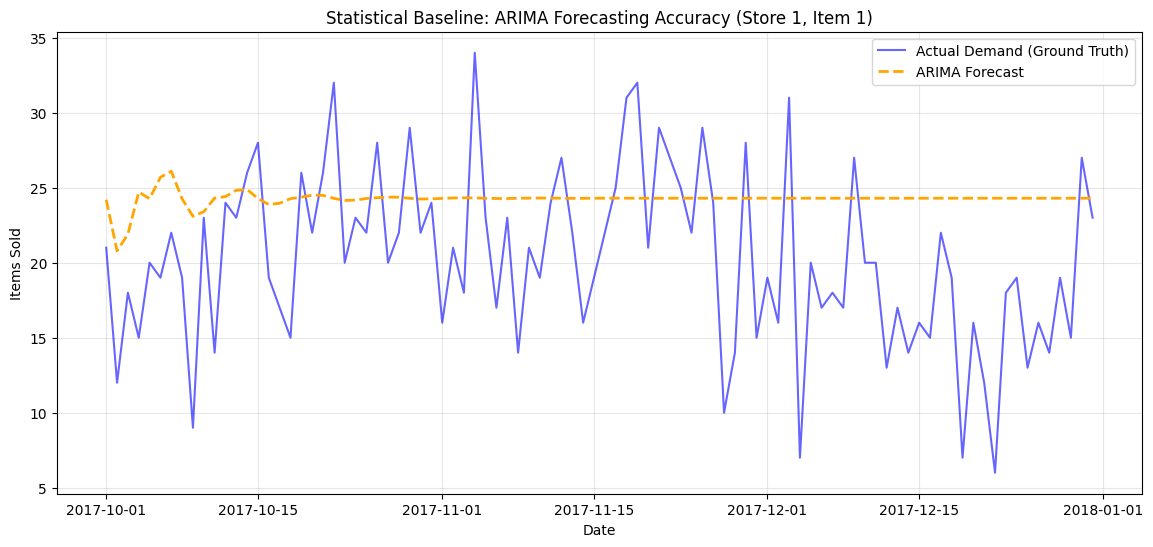

In [14]:
from statsmodels.tsa.arima.model import ARIMA

# Isolate Data to store 1, item 1
baseline_df = train_df[(train_df['store'] == 1) & (train_df['item'] == 1)].copy()
baseline_df = baseline_df.sort_values('date')

# Train / Test Split 
train_arima = baseline_df[baseline_df['date'] < split_date]['sales'].values
test_arima = baseline_df[baseline_df['date'] >= split_date]['sales'].values
test_dates = baseline_df[baseline_df['date'] >= split_date]['date'].values

# Traditional ARIMA Model
arima_model = ARIMA(train_arima, order=(7, 1, 1))
arima_fit = arima_model.fit()

# Generate Forecast
arima_predictions = arima_fit.forecast(steps=len(test_arima))

# Calculate SMAPE
def calculate_smape(actual, predicted):
    epsilon = 0.1
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0 + epsilon
    diff = np.abs(actual - predicted) / denominator
    return 100 * np.mean(diff)

arima_smape = calculate_smape(test_arima, arima_predictions)

print("\n--- THE SHOWDOWN (Store 1, Item 1) ---")
print(f"ARIMA SMAPE: {arima_smape:.2f}%")
print(f"LSTM SMAPE:  ~20.96% (From your earlier test)")

# --- 6. Plot the Statistical Baseline ---
plt.figure(figsize=(14, 6))
plt.plot(test_dates, test_arima, label='Actual Demand (Ground Truth)', color='blue', alpha=0.6)
plt.plot(test_dates, arima_predictions, label='ARIMA Forecast', color='orange', linestyle='--', linewidth=2)
plt.title('Statistical Baseline: ARIMA Forecasting Accuracy (Store 1, Item 1)')
plt.xlabel('Date')
plt.ylabel('Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()